# CNN


Import and extract the zip file

In [ ]:
import zipfile
import os

with zipfile.ZipFile("datasetc.zip", 'r') as zip_ref:
    zip_ref.extractall()

os.listdir()

dataset_path = './cars datasets/train'


Preprocessing the images

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    './cars datasets/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    './cars datasets/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'  # red vs blue
)

Found 27 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
Found 27 images belonging to 2 classes.


Training the CNN model

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary output
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=10
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.4444 - loss: 0.6977
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5556 - loss: 3.7939
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4444 - loss: 1.4394
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4444 - loss: 0.8424
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9630 - loss: 0.4664
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5556 - loss: 0.5713
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8148 - loss: 0.3957
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.2861
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.2055
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.1045


Code to input image url and display the accuracy

enter image url : https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR9mlzBlVK-G5iUgBILTdo1_cBTu6iYZnhYEw&s


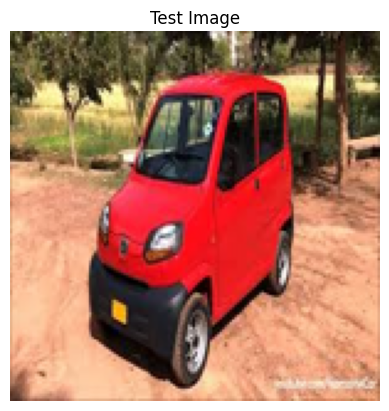

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted: Red Car
Prediction Score: 0.9980


In [ ]:
import requests
from PIL import Image
import numpy as np
import io
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_url = input("enter image url : ")

response = requests.get(img_url)
img = Image.open(io.BytesIO(response.content)).convert('RGB')


img = img.resize((150, 150))

# Show image
plt.imshow(img)
plt.axis('off')
plt.title('Test Image')
plt.show()

# Convert image to numpy array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Normalize pixel values
img_array /= 255.0

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Predicted: Red Car")
else:
    print("Predicted: Blue Car")

print(f"Prediction Score: {prediction[0][0]:.4f}")

# SVM

Extracting features(R,G,B,class) from the dataset using cv2 library

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd


def extract_features(img):
    return  list(cv2.mean(im))[:3]


data=[]
basepath='./cars datasets/train'
for folder in os.scandir(basepath):
    if folder.is_dir():
        #print(folder.name)
        for file in os.scandir(folder.path):
            im=cv2.imread(file.path)
            im=cv2.cvtColor(im,cv2.COLOR_BGR2RGB)
            features=extract_features(im)
            features.append(folder.name)
            data.append(features)
            #print(features)

In [ ]:
print(data)

[[107.1416894627421, 134.66459131195973, 162.59578728526097, 'blue'], [95.46727044701245, 104.47431335662456, 119.4953202544119, 'blue'], [100.54484250977373, 112.59812966473167, 137.57881730541405, 'blue'], [82.51572435050639, 92.14295244385734, 105.85833443416998, 'blue'], [54.10767862842552, 46.541439628835896, 34.571437120970316, 'blue'], [87.77674370659722, 91.40833658854167, 105.14547960069444, 'blue'], [76.95386019283747, 77.32042011019284, 96.25904614325069, 'blue'], [201.40386429980276, 206.62776962524654, 213.76844812623276, 'blue'], [99.63754328387793, 99.23256332099407, 104.2837434946516, 'blue'], [156.0998936735779, 158.61437887648415, 164.72031189083822, 'blue'], [66.75683116912842, 72.36881923675537, 107.83020644717746, 'blue'], [127.01743659420289, 127.89527541482882, 136.4712901701323, 'blue'], [128.48296133333335, 107.39185333333334, 125.00292133333335, 'red'], [75.75721674337059, 54.659057637519176, 58.256116589962744, 'red'], [139.76843359375, 111.13484244791667, 80

Converting the extracted data to a dataframe

In [ ]:
df = pd.DataFrame(data, columns=['R','G','B','class'])
df.to_csv('curdata.csv',index=False)

df = pd.read_csv('curdata.csv')
print(df)

             R           G           B class
0   107.141689  134.664591  162.595787  blue
1    95.467270  104.474313  119.495320  blue
2   100.544843  112.598130  137.578817  blue
3    82.515724   92.142952  105.858334  blue
4    54.107679   46.541440   34.571437  blue
5    87.776744   91.408337  105.145480  blue
6    76.953860   77.320420   96.259046  blue
7   201.403864  206.627770  213.768448  blue
8    99.637543   99.232563  104.283743  blue
9   156.099894  158.614379  164.720312  blue
10   66.756831   72.368819  107.830206  blue
11  127.017437  127.895275  136.471290  blue
12  128.482961  107.391853  125.002921   red
13   75.757217   54.659058   58.256117   red
14  139.768434  111.134842   80.705742   red
15  200.383095  173.252992  173.598067   red
16   64.013535   32.755530   36.023027   red
17  152.177088   97.718812   98.534306   red
18   76.080817   40.470505   49.156888   red
19  143.622202   69.823908   76.280786   red
20   97.794167   79.543838   53.205976   red
21  150.60

In [ ]:
import pandas as pd

df['class'] = df['class'].map({'red': 0, 'blue': 1})

X = df[['R', 'G', 'B']].values  # RGB features
y = df['class'].values         # Labels: 0 for red, 1 for blue

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Training the SVM model

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)


SVC()

In [ ]:
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")


Test Accuracy: 0.67


Code to input image url and view accuracy

Enter image url : https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSclBbUPES9xpGZQU8vkXDOSsLb9kTL0AB7KQ&s
It is a blue car


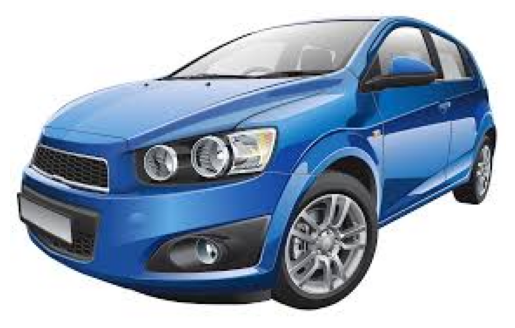

SVM Accuracy: 0.67


In [ ]:
import urllib.request

def get_image(url):


  with urllib.request.urlopen(url) as response:
      image_data = response.read()

  image_array = np.array(bytearray(image_data), dtype=np.uint8)

  # Decode the image array into an OpenCV image
  image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
  return image

  import matplotlib.pyplot as plt

url=input("Enter image url : ")
im=get_image(url)
im=cv2.cvtColor(im,cv2.COLOR_BGR2RGB)
features=extract_features(im)
yp=classifier.predict([features])
yp=le.inverse_transform(yp)

print('It is a '+yp[0] , 'car')
plt.axis("off")
plt.imshow(im)
plt.show()

from sklearn.metrics import accuracy_score

y_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy: {svm_accuracy:.2f}")

Comparing both models accuracy

In [ ]:
print(f"CNN Prediction Score: {prediction[0][0]:.3f}")
print(f"SVM Accuracy: {svm_accuracy:.3f}")

CNN Prediction Score: 0.998
SVM Accuracy: 0.667
